In [1]:
%matplotlib inline
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
import matplotlib.animation as animation
from scipy import signal

In [2]:
def plot_diff_frames(frames,index,index2):
    # plot 2x5 subplots 
    fig, axs = plt.subplots(2, len(frames[index]), figsize=(30, 15))
    for i in range(len(frames[index])):
        axs[0, i].imshow(frames[index][i])
        axs[1, i].imshow(frames[index2][i])
        axs[0, i].set_title('frame ' + str(i))
        axs[1, i].set_title('frame ' + str(i))
    plt.show()

In [3]:
def plot_results(avg_intensity_frames):
    # ploting the average intensity of the average frames
    if len(avg_intensity_frames) > 100:
        for i in range(0, len(avg_intensity_frames), 100):
            plt.figure(figsize=(30, 10))
            plt.xticks(np.arange(0, len(avg_intensity_frames[i:i+100]), 1))
            plt.plot(avg_intensity_frames[i:i+100])
            plt.show()
    else:
        plt.figure(figsize=(20, 10))
        plt.xticks(np.arange(0, len(avg_intensity_frames), 1))
        plt.plot(avg_intensity_frames)
        plt.show()

In [10]:
# get the index of the biggest difference between the frames
def get_index_of_biggest_difference(avg_intensity_frames):
    # getting the index of the biggest difference between the frames
    index_of_biggest_difference = []
    for i in range(len(avg_intensity_frames)-1):
        index_of_biggest_difference.append(abs(avg_intensity_frames[i] - avg_intensity_frames[i+1]))

    index_of_biggest_difference = np.argmax(index_of_biggest_difference)
    return index_of_biggest_difference

In [4]:
def applied_method(cap, frames_to_take):
    
    # getting the frame rate
    fps = cap.get(cv.CAP_PROP_FPS)
    # getting the frame count
    frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    
    frames = []
    gray_frames = []
    for i in range(0, frame_count, frames_to_take):
        ls = []
        ls2 = []
        for j in range(i,i+frames_to_take):
            ret, frame = cap.read()
            if ret == False:
                break
            else:
                # normalizing the frame
                gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
                gray = cv.normalize(gray, None, 0, 255, cv.NORM_MINMAX, cv.CV_8UC3)
                ls2.append(gray)
                ls.append(frame)
        if len(ls) == frames_to_take:
            gray_frames.append(ls2)
            frames.append(ls)

    # avg of each row in gray_frames
    avg_ls = []
    for row in gray_frames:
        avg_image = row[0]
        for i in range(len(row)):
            if i == 0:
                pass
            else:
                alpha = 1.0/(i + 1)
                beta = 1.0 - alpha
                avg_image = cv.addWeighted(avg_image, alpha, row[i], beta, 0.0)
        avg_ls.append(avg_image)



    # calculate the average intensity of the average frames
    avg_intensity_frames = []
    
    for i in range(len(avg_ls)):
        avg_intensity_frames.append(np.mean(avg_ls[i]))


    return avg_intensity_frames, frames

# Alignments and stabilization

### preliminary test

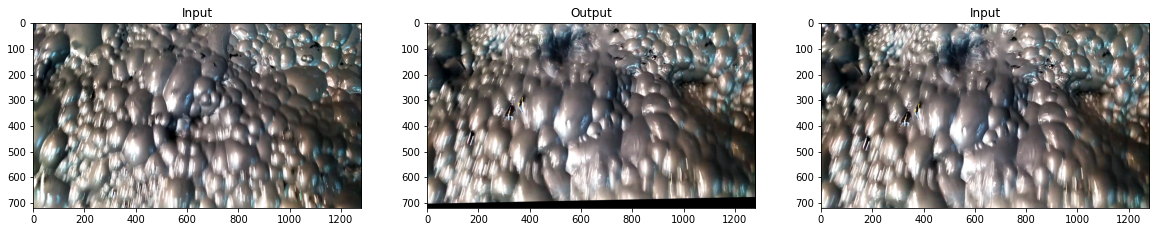

In [5]:


# reading the video
cap = cv.VideoCapture('rl4_pb17-4.mp4')

# gettin frame number 33
cap.set(1, 33)
ret, frame1 = cap.read()

cap.set(1, 39)
ret, frame2 = cap.read()

# converting to gray
gray1 = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

size = frame1.shape

# define the motion model
warp_mode = cv.MOTION_EUCLIDEAN

# define 2x3 or 3x3 matrices and initialize the matrix to identity
if warp_mode == cv.MOTION_HOMOGRAPHY :
    warp_matrix = np.eye(3, 3, dtype=np.float32)
else :
    warp_matrix = np.eye(2, 3, dtype=np.float32)

# specify the number of iterations.
number_of_iterations = 5000;

# specify the threshold of the increment
# in the correlation coefficient between two iterations
termination_eps = 1e-10;

# define termination criteria
criteria = (cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, number_of_iterations,  termination_eps)

# Run the ECC algorithm. The results are stored in warp_matrix.
(cc, warp_matrix) = cv.findTransformECC (gray1,gray2,warp_matrix, warp_mode, criteria)

if warp_mode == cv.MOTION_HOMOGRAPHY :
    # Use warpPerspective for Homography 
    im1_aligned = cv.warpPerspective (frame2, warp_matrix, (size[1],size[0]), flags=cv.INTER_LINEAR + cv.WARP_INVERSE_MAP)
else :
    # Use warpAffine for Translation, Euclidean and Affine
    im1_aligned = cv.warpAffine(frame2, warp_matrix, (size[1],size[0]), flags=cv.INTER_LINEAR + cv.WARP_INVERSE_MAP);

# ploting the results
plt.figure(figsize=(20,10))
plt.subplot(131),plt.imshow(frame1),plt.title('Input')
plt.subplot(132),plt.imshow(im1_aligned),plt.title('Output')
plt.subplot(133),plt.imshow(frame2),plt.title('Input')
plt.show()



In [6]:
from vidstab import VidStab

stabilizer = VidStab()
stabilizer.stabilize(input_path='rl4_pb17-4.mp4', output_path='stable_video.avi')

video fps: 29.0
video frame count: 938 ,frames tooked into consideration: 5 , values = 187.6


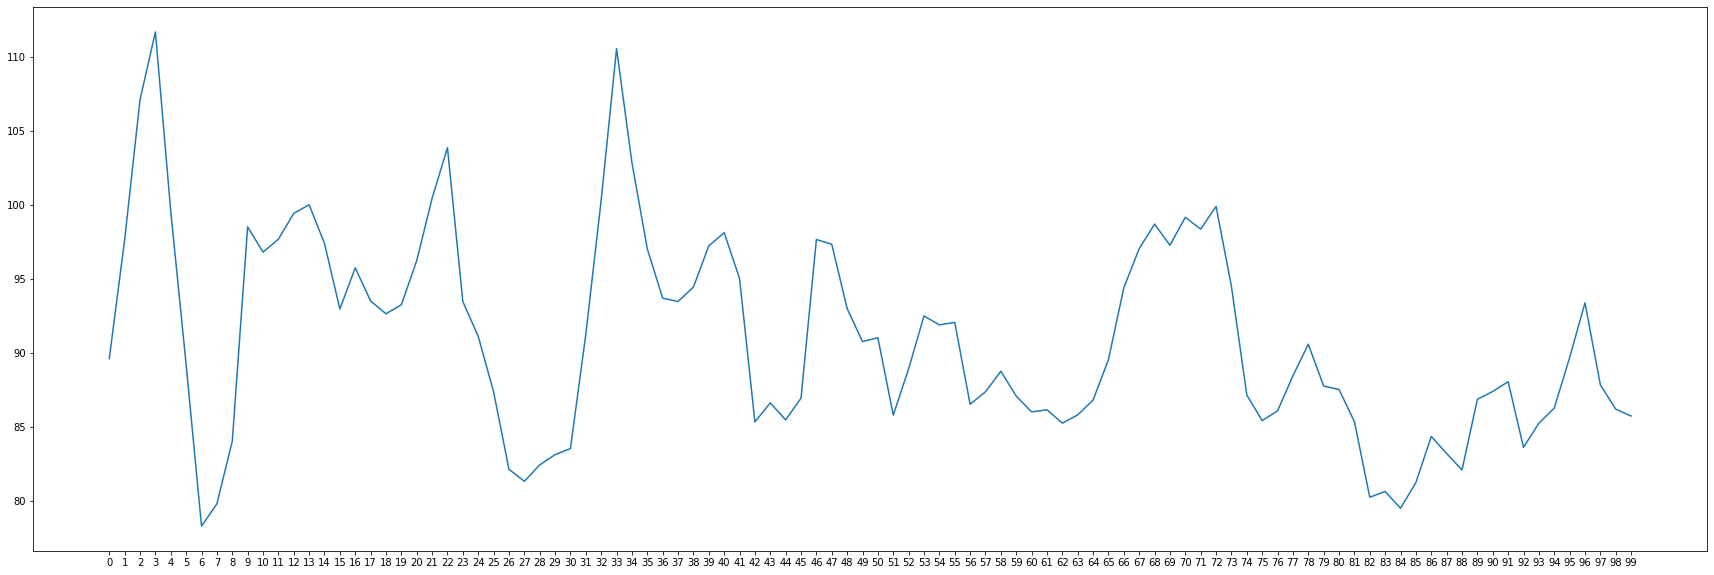

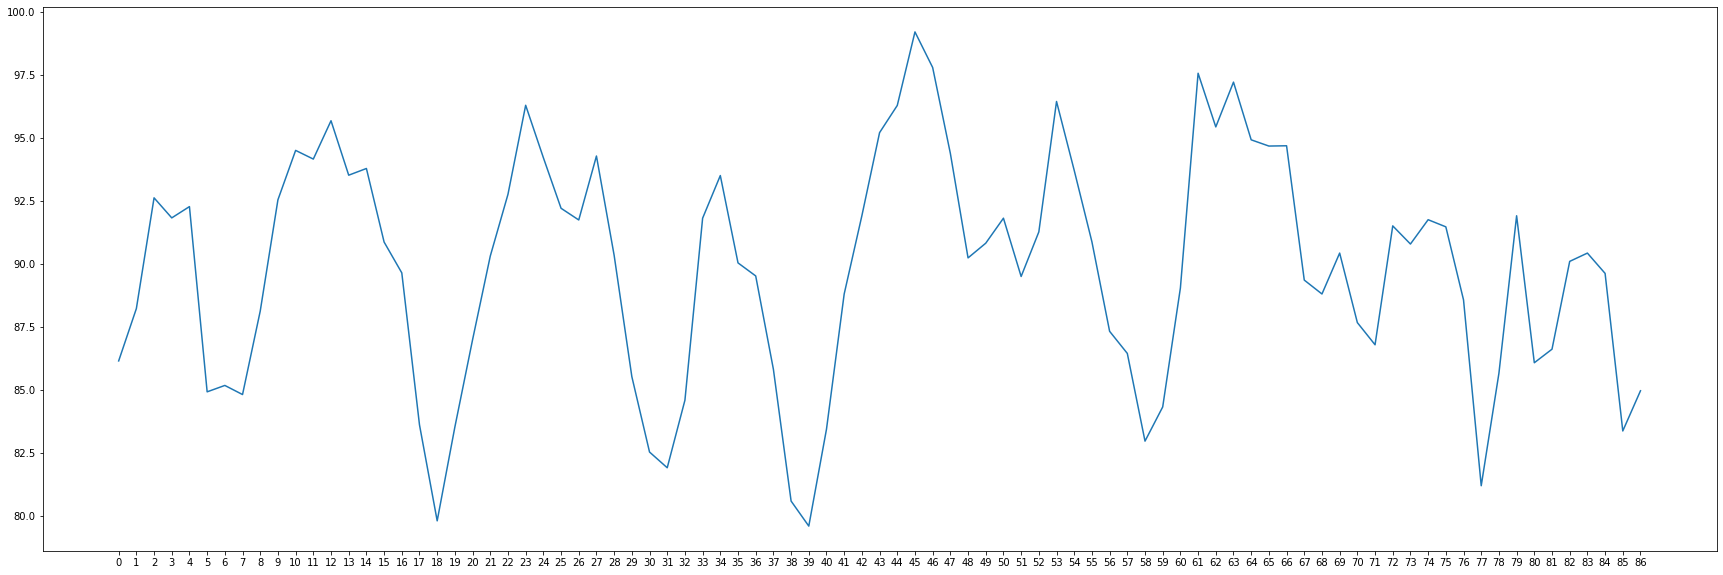

In [7]:
# applying the method to the stabilized video
cap = cv.VideoCapture('stable_video.avi')

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

frames_to_take = int(input("Enter the number of frames to take: "))

print(f"video frame count: {frame_count} ,frames tooked into consideration: {frames_to_take} , values = {frame_count/frames_to_take}")

# applying the method to the video

avg_intensity_frames4, frames4 = applied_method(cap, frames_to_take)

# ploting the average intensity of the average frames
plot_results(avg_intensity_frames4)

index of the biggest difference: 8 , 9 and the difference is: 84.047919921875 - 98.51305013020833 = 14.46513020833332


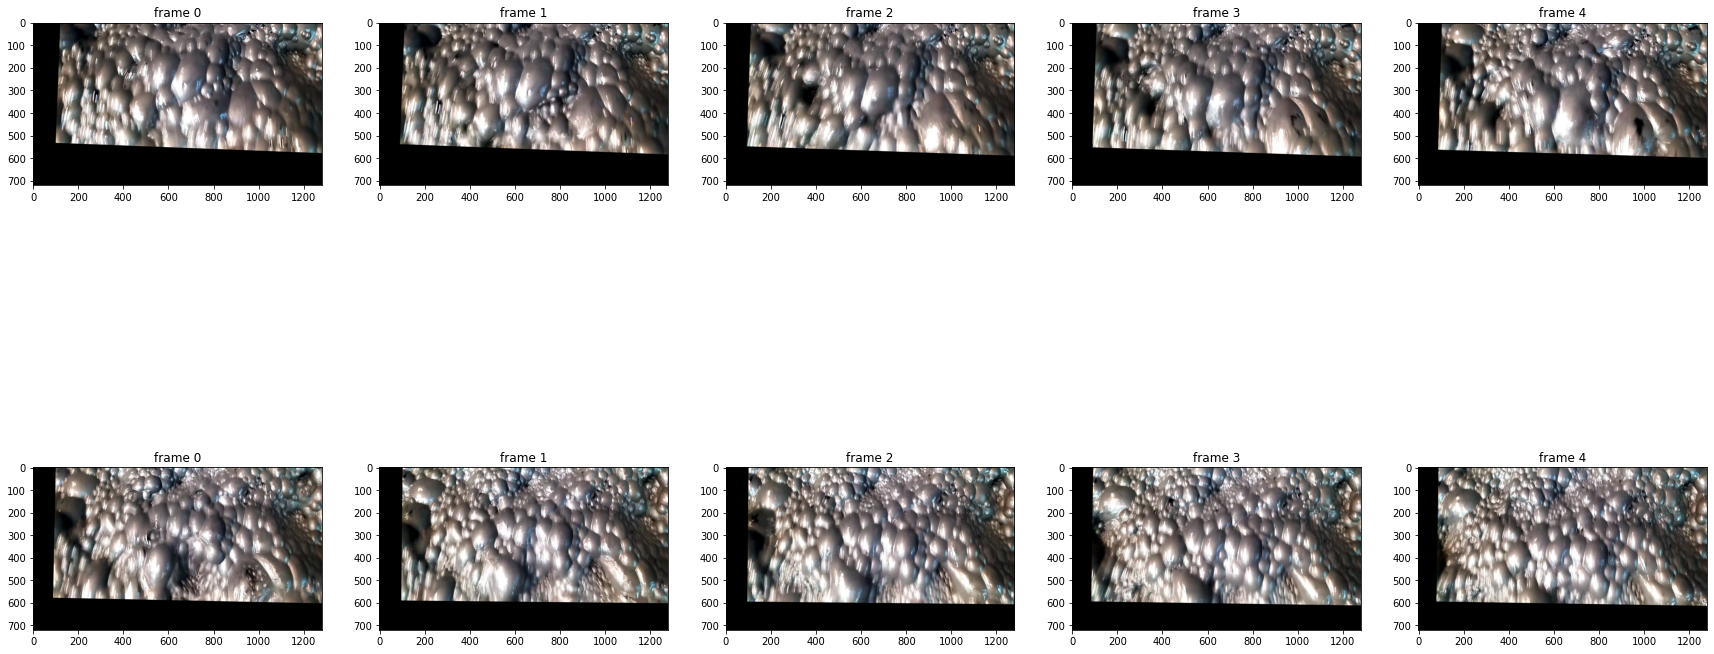

In [11]:
index_of_biggest_difference = get_index_of_biggest_difference(avg_intensity_frames4)

print(f"index of the biggest difference: {index_of_biggest_difference} , {index_of_biggest_difference + 1} and the difference is: {avg_intensity_frames4[index_of_biggest_difference]} - {avg_intensity_frames4[index_of_biggest_difference+1]} = {abs(avg_intensity_frames4[index_of_biggest_difference] - avg_intensity_frames4[index_of_biggest_difference+1])}")

plot_diff_frames(frames4,index_of_biggest_difference, index_of_biggest_difference + 1)

# Conclusion
The stabilization of the video is not a good idea, because it will make the process slower and it will not give us a good understanding of the stability of the froth. also the alignment give the black edges which is not good for the process.